# 📚 Part 1: TF-IDF Vectorization — Mathematical Foundations & Scratch Equivalence

## 🎯 Learning Objectives & Overview
In classical and modern Natural Language Processing (NLP), machine learning models (such as **Support Vector Machines**, **Logistic Regression**, and **Gradient Boosted Trees**) cannot directly ingest raw text or discrete token lists. Instead, documents must be mapped into real-valued numeric feature vectors.

The most foundational, robust, and computationally scalable technique for this is **TF-IDF (Term Frequency – Inverse Document Frequency)** vectorization.

```mermaid
flowchart TD
    subgraph INPUT["1. Input Documents"]
        D1["Doc 1: 'the apple is red'"]
        D2["Doc 2: 'the sky is blue'"]
        D3["Doc 3: 'the red apple and blue sky'"]
        D4["Doc 4: 'delicious sweet red apple'"]
    end

    subgraph TF["2. Term Frequency (TF)"]
        TF1["Local Occurrence Count:<br/>tf(t, d) = f_{t,d}"]
        TF2["Optional Sublinear Scaling:<br/>tf_sub = 1 + ln(f_{t,d})"]
    end

    subgraph IDF["3. Inverse Document Frequency (IDF)"]
        IDF1["Global Rarity Weight:<br/>idf(t) = ln((1+N)/(1+df(t))) + 1"]
        IDF2["Penalizes frequent stopwords<br/>('the', 'is')"]
        IDF3["Rewards rare discriminative terms<br/>('apple', 'blue', 'delicious')"]
    end

    subgraph COMBINE["4. Product & L2 Normalization"]
        RAW["Raw Weight = TF × IDF"]
        NORM["Unit Hypersphere Projection:<br/>v_norm = v / ||v||_2"]
    end

    subgraph OUTPUT["5. Feature Representation"]
        SPARSE["Compressed Sparse Row (CSR) Matrix<br/>Memory-efficient & ready for LinearSVC"]
    end

    INPUT --> TF
    INPUT --> IDF
    TF --> RAW
    IDF --> RAW
    RAW --> NORM
    NORM --> SPARSE
```

---

### What Part 1 Covers:
1. **The Bag-of-Words Dilemma:** Why raw word counting fails for discriminative text classification.
2. **The Exact Scikit-Learn Mathematics:** Deconstructing `smooth_idf=True`, logarithmic scaling, and $L_2$ Euclidean normalization.
3. **From-Scratch Verification:** Writing a pure NumPy implementation and proving exact numerical equivalence ($\Delta = 0.00$) against Scikit-Learn.
4. **Sublinear TF Scaling:** Suppressing bursty, repetitive word spam with $1 + \ln(\text{tf})$.

*(Note: For N-gram modeling, Markov transitions, and real-world token sequence classification on `train.json`, see **Part 2**).*

## 1. Environment Setup & Core Dependencies

We import the essential scientific computing libraries:
- `numpy` & `scipy.sparse`: High-performance numerical linear algebra and sparse matrix operations.
- `pandas`: Tabular visualization of vocabulary matrices and intermediate step metrics.
- `sklearn.feature_extraction.text`: Scikit-Learn's industry standard `TfidfVectorizer` and `CountVectorizer`.
- `matplotlib.pyplot` & `seaborn`: Plotting distributions, damping curves, and heatmaps.

In [1]:
import os
import math
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configure visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=4, suppress=True)

print("Environment configured successfully!")
print(f"NumPy Version: {np.__version__} | Pandas Version: {pd.__version__}")


Environment configured successfully!
NumPy Version: 2.4.6 | Pandas Version: 3.0.5


## 2. The Intuition: Bag-of-Words vs. TF-IDF Weighting

### The Failure of Raw CountVectorizer (Bag-of-Words)
In raw frequency counting, every occurrence of a word receives an identical weight of $+1$:
$$\text{Count}(t, d) = f_{t, d}$$

```
Document 1: "the apple is red"           -> 'the': 1, 'apple': 1, 'is': 1, 'red': 1
Document 2: "the sky is blue"            -> 'the': 1, 'sky': 1,   'is': 1, 'blue': 1
Document 3: "the red apple and blue sky" -> 'the': 1, 'apple': 1, 'is': 0, 'red': 1, ...
Document 4: "delicious sweet red apple"  -> 'the': 0, 'apple': 1, 'delicious': 1, ...
```

#### Why raw counts hurt classification models:
1. **Stopword Domination:** Common filler words (`"the"`, `"is"`, `"and"`) appear in almost every document. Their large raw counts dominate Euclidean distance and vector dot products, obscuring topical keywords like `"apple"` or `"sky"`.
2. **Document Length Bias:** A verbose document mentioning a generic word 10 times appears artificially more "similar" than a concise document containing the exact key terms.

### The TF-IDF Solution
TF-IDF balances **two competing forces**:
1. **Term Frequency (TF):** Rewards words that appear frequently within a *specific document* (local topic relevance).
2. **Inverse Document Frequency (IDF):** Penalizes words that appear across *many documents* in the corpus (global commonality).

$$\text{TF-IDF}(t, d) = \underbrace{\text{TF}(t, d)}_{\text{Local Importance}} \times \underbrace{\text{IDF}(t)}_{\text{Global Informative Power}}$$

In [2]:
# Define a clean pedagogical toy corpus using intuitive words
toy_corpus = [
    "the apple is red",
    "the sky is blue",
    "the red apple and the blue sky",
    "delicious sweet red apple"
]

print("--- Pedagogical Toy Corpus (N = 4 documents) ---")
for idx, doc in enumerate(toy_corpus, 1):
    print(f"Doc {idx}: '{doc}'")

# Compute raw Bag-of-Words using CountVectorizer
count_vec = CountVectorizer()
X_counts = count_vec.fit_transform(toy_corpus)
vocab = count_vec.get_feature_names_out()

df_counts = pd.DataFrame(X_counts.toarray(), columns=vocab, index=[f"Doc {i}" for i in range(1, 5)])
print("\n--- Raw CountVectorizer Matrix (Frequency Counts) ---")
display(df_counts)

print("\nNotice how common words like 'the' and 'red' appear across almost all documents.")


--- Pedagogical Toy Corpus (N = 4 documents) ---
Doc 1: 'the apple is red'
Doc 2: 'the sky is blue'
Doc 3: 'the red apple and the blue sky'
Doc 4: 'delicious sweet red apple'

--- Raw CountVectorizer Matrix (Frequency Counts) ---


,and,apple,blue,delicious,is,red,sky,sweet,the
Doc 1,0,1,0,0,1,1,0,0,1
Doc 2,0,0,1,0,1,0,1,0,1
Doc 3,1,1,1,0,0,1,1,0,2
Doc 4,0,1,0,1,0,1,0,1,0



Notice how common words like 'the' and 'red' appear across almost all documents.


## 3. Mathematical Anatomy of Scikit-Learn's TF-IDF Formulation

Let $N$ denote the total number of documents in the corpus, and let $\text{df}(t)$ denote the document frequency of term $t$ (the number of documents containing term $t$).

---

### Step 1: Term Frequency (TF)
In standard Scikit-Learn `TfidfVectorizer(sublinear_tf=False)`:
$$\text{tf}(t, d) = f_{t, d}$$
where $f_{t, d}$ is the raw count of term $t$ in document $d$.

---

### Step 2: Smoothed Inverse Document Frequency (Smoothed IDF)
Scikit-Learn uses **smoothed IDF** by default (`smooth_idf=True`):
$$\text{idf}(t) = \ln\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1$$

> [!NOTE]
> **Why the '+1' in numerator, denominator, and outside the logarithm?**
> 1. Adding $+1$ to numerator and denominator $\frac{1 + N}{1 + \text{df}(t)}$ prevents **division by zero** if an unseen test word has $\text{df}(t) = 0$.
> 2. Adding $+1$ outside the logarithm ensures that words appearing in all documents (where $\text{df}(t) = N$) receive a non-zero minimum weight:
>    $$\text{idf}(t) = \ln\left(\frac{1 + N}{1 + N}\right) + 1 = \ln(1) + 1 = 0 + 1 = 1.0$$
>    Without the outer $+1$, words appearing in all documents would be completely zeroed out ($\text{idf} = 0$).

---

### Step 3: Raw TF-IDF Matrix Entry
$$\text{tfidf}_{\text{raw}}(t, d) = \text{tf}(t, d) \times \text{idf}(t)$$

---

### Step 4: Euclidean $L_2$ Vector Normalization
To prevent long documents from dominating short documents, each document row vector $\mathbf{v}_d$ is projected onto the **unit hypersphere** ($\|\mathbf{v}_d\|_2 = 1$):

$$\mathbf{v}_d = \frac{\mathbf{v}_d^{\text{raw}}}{\|\mathbf{v}_d^{\text{raw}}\|_2} = \frac{\mathbf{v}_d^{\text{raw}}}{\sqrt{\sum_{j=1}^{V} \left(\text{tfidf}_{\text{raw}}(t_j, d)\right)^2}}$$

This step guarantees that cosine similarity between two documents simplifies directly to their **inner dot product**:
$$\cos(\theta_{\mathbf{u}, \mathbf{v}}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2} = \mathbf{u} \cdot \mathbf{v}$$

In [3]:
def manual_tfidf_step_by_step(corpus, sublinear_tf=False):
    '''
    Implements Scikit-Learn's exact TfidfVectorizer algorithm from scratch.
    '''
    # 1. Build Vocabulary
    tokenized_docs = [doc.lower().split() for doc in corpus]
    all_tokens = sorted(list(set(token for doc in tokenized_docs for token in doc)))
    vocab_map = {token: idx for idx, token in enumerate(all_tokens)}
    N = len(corpus)
    V = len(all_tokens)

    # 2. Compute Document Frequency df(t)
    df_counts = np.zeros(V, dtype=np.float64)
    for doc in tokenized_docs:
        unique_tokens = set(doc)
        for token in unique_tokens:
            df_counts[vocab_map[token]] += 1

    # 3. Compute Smoothed IDF: ln((1 + N)/(1 + df)) + 1
    smoothed_idf = np.log((1 + N) / (1 + df_counts)) + 1.0

    # 4. Compute Term Frequency (TF) Matrix
    tf_matrix = np.zeros((N, V), dtype=np.float64)
    for row_idx, doc in enumerate(tokenized_docs):
        for token in doc:
            col_idx = vocab_map[token]
            tf_matrix[row_idx, col_idx] += 1

    if sublinear_tf:
        # tf_sub = 1 + ln(tf) if tf > 0 else 0
        tf_matrix = np.where(tf_matrix > 0, 1.0 + np.log(tf_matrix), 0.0)

    # 5. Raw TF-IDF Weight = TF * IDF
    raw_tfidf = tf_matrix * smoothed_idf

    # 6. Row-wise Euclidean L2 Normalization
    norms = np.linalg.norm(raw_tfidf, axis=1, keepdims=True)
    norms[norms == 0] = 1.0  # Prevent division by zero
    normalized_tfidf = raw_tfidf / norms

    return {
        'vocab': all_tokens,
        'df': df_counts,
        'idf': smoothed_idf,
        'tf': tf_matrix,
        'raw_tfidf': raw_tfidf,
        'final_tfidf': normalized_tfidf
    }

# Execute scratch implementation
scratch_res = manual_tfidf_step_by_step(toy_corpus, sublinear_tf=False)

# Display IDF Weights Table
df_idf_report = pd.DataFrame({
    'Term': scratch_res['vocab'],
    'Doc Frequency (df)': scratch_res['df'].astype(int),
    'Corpus Frequency (N)': len(toy_corpus),
    'Formula (1+N)/(1+df)': [(1 + len(toy_corpus)) / (1 + df) for df in scratch_res['df']],
    'Calculated IDF Weight': scratch_res['idf']
}).sort_values(by='Calculated IDF Weight', ascending=True).reset_index(drop=True)

print("--- Step 1 & 2: Calculated IDF Weights (Rarity Penalization) ---")
display(df_idf_report)
print("Notice: 'the' and 'red' have lowest IDF (1.2231) because df=3, while 'delicious' has highest IDF (1.9163) because df=1!")


--- Step 1 & 2: Calculated IDF Weights (Rarity Penalization) ---


,Term,Doc Frequency (df),Corpus Frequency (N),Formula (1+N)/(1+df),Calculated IDF Weight
0,apple,3,4,1.250000,1.223144
1,red,3,4,1.250000,1.223144
2,the,3,4,1.250000,1.223144
3,is,2,4,1.666667,1.510826
4,sky,2,4,1.666667,1.510826
5,blue,2,4,1.666667,1.510826
6,delicious,1,4,2.500000,1.916291
7,and,1,4,2.500000,1.916291
8,sweet,1,4,2.500000,1.916291


Notice: 'the' and 'red' have lowest IDF (1.2231) because df=3, while 'delicious' has highest IDF (1.9163) because df=1!


## 4. Scikit-Learn Verification & Numerical Equivalence Proof

To verify our understanding of the mathematical underpinnings, we benchmark our scratch implementation against Scikit-Learn's `TfidfVectorizer(smooth_idf=True, norm='l2', sublinear_tf=False)`.

```mermaid
graph TD
    DOCS[Toy Corpus] --> SCRATCH[Our NumPy Scratch Formula]
    DOCS --> SKLEARN[Scikit-Learn TfidfVectorizer]
    SCRATCH --> DIFF[Calculate Max Absolute Diff:<br/>max|X_scratch - X_sklearn|]
    SKLEARN --> DIFF
    DIFF --> VERDICT{Diff < 1e-15 ?}
    VERDICT -->|YES| PASS[✅ Mathematical Equivalence Confirmed]
```

Maximum absolute difference between Scratch and Scikit-Learn: 0.00e+00
⭐ VERIFICATION SUCCESSFUL: Scratch implementation is mathematically IDENTICAL to Scikit-Learn!


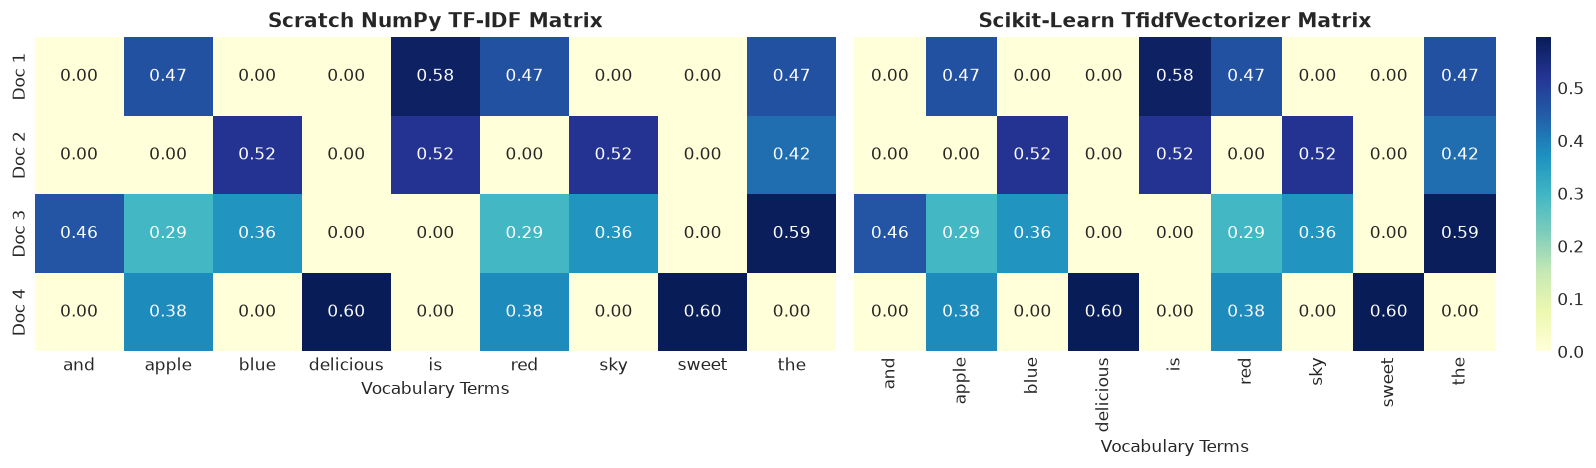

In [4]:
# Fit Scikit-Learn's TfidfVectorizer
sklearn_vec = TfidfVectorizer(
    smooth_idf=True,
    norm='l2',
    sublinear_tf=False,
    token_pattern=r'(?u)\b\w+\b'
)

X_sklearn = sklearn_vec.fit_transform(toy_corpus).toarray()
sklearn_vocab = list(sklearn_vec.get_feature_names_out())

# Extract matrices
scratch_matrix = scratch_res['final_tfidf']

# Align columns to guarantee identical vocabulary sorting
scratch_df = pd.DataFrame(scratch_matrix, columns=scratch_res['vocab'], index=[f"Doc {i}" for i in range(1, 5)])
sklearn_df = pd.DataFrame(X_sklearn, columns=sklearn_vocab, index=[f"Doc {i}" for i in range(1, 5)])

# Compute maximum absolute discrepancy
max_diff = np.max(np.abs(scratch_df.values - sklearn_df.values))

print(f"Maximum absolute difference between Scratch and Scikit-Learn: {max_diff:.2e}")
if max_diff < 1e-12:
    print("⭐ VERIFICATION SUCCESSFUL: Scratch implementation is mathematically IDENTICAL to Scikit-Learn!")
else:
    print("Discrepancy detected!")

# Visual side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
sns.heatmap(scratch_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar=False, ax=axes[0])
axes[0].set_title("Scratch NumPy TF-IDF Matrix", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Vocabulary Terms")

sns.heatmap(sklearn_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, ax=axes[1])
axes[1].set_title("Scikit-Learn TfidfVectorizer Matrix", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Vocabulary Terms")

plt.tight_layout()
plt.show()


## 5. Sublinear TF Scaling ($1 + \ln(\text{tf})$): Taming Repetition

### The Problem with Linear Term Frequency
In standard TF-IDF, a document that repeats the word `"apple"` **20 times** receives a term frequency score $20\times$ larger than a document with 1 occurrence:
$$\text{tf}_{\text{linear}}(t, d) = 20 \times \text{tf}_{\text{linear}}(\text{apple}, d')$$

However, from an **Information Theory** standpoint:
> *Does seeing a word 20 times impart 20 times more information than seeing it once?*
> **No.** It exhibits diminishing marginal information returns. Excessive repetition often reflects stylistic habit, keyword stuffing, or generator loops.

### The Sublinear Formulation
When enabling `sublinear_tf=True`, Scikit-Learn applies logarithmic damping:

$$\text{tf}_{\text{sub}}(t, d) = \begin{cases} 1 + \ln(f_{t, d}) & \text{if } f_{t, d} > 0 \\ 0 & \text{otherwise} \end{cases}$$

```
Raw Count f_{t,d}    Linear TF    Sublinear TF (1 + ln(f))    Damping Effect
─────────────────────────────────────────────────────────────────────────────
        1                1.0                1.0000              Baseline
        2                2.0                1.6931              -15.3%
        5                5.0                2.6094              -47.8%
       10               10.0                3.3026              -67.0%
       25               25.0                4.2189              -83.1%
       50               50.0                4.9120              -90.2%
```

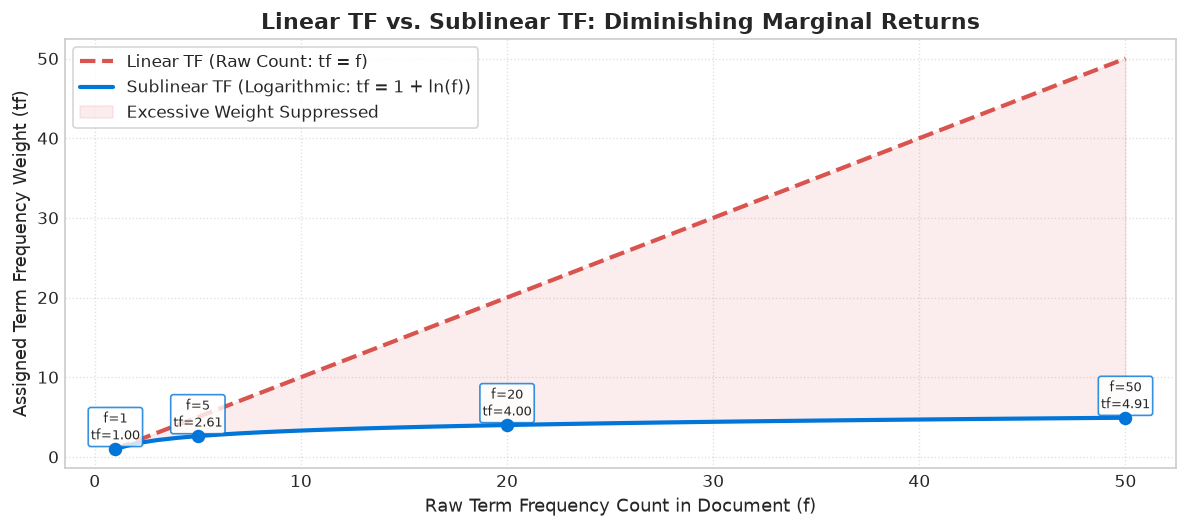

In [5]:
# Generate frequency spectrum from 1 to 50
raw_counts = np.arange(1, 51)
linear_tf = raw_counts
sublinear_tf = 1 + np.log(raw_counts)

plt.figure(figsize=(10, 4.5))
plt.plot(raw_counts, linear_tf, label="Linear TF (Raw Count: tf = f)", color="#d9534f", linewidth=2.5, linestyle="--")
plt.plot(raw_counts, sublinear_tf, label="Sublinear TF (Logarithmic: tf = 1 + ln(f))", color="#0275d8", linewidth=2.5)

plt.fill_between(raw_counts, sublinear_tf, linear_tf, color="#d9534f", alpha=0.1, label="Excessive Weight Suppressed")
plt.title("Linear TF vs. Sublinear TF: Diminishing Marginal Returns", fontsize=13, fontweight='bold')
plt.xlabel("Raw Term Frequency Count in Document (f)", fontsize=11)
plt.ylabel("Assigned Term Frequency Weight (tf)", fontsize=11)
plt.legend(frameon=True, facecolor='white', loc='upper left', fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)

# Highlight specific points
for pt in [1, 5, 20, 50]:
    plt.scatter(pt, 1 + np.log(pt), color="#0275d8", s=50, zorder=5)
    plt.text(pt, (1 + np.log(pt)) + 1.2, f"f={pt}\ntf={1+np.log(pt):.2f}", fontsize=8, ha='center',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#0275d8', alpha=0.8))

plt.tight_layout()
plt.show()


## 6. Summary of Part 1 & Next Steps

In Part 1, we derived and verified the core linear algebra of TF-IDF vectorization:
1. **TF-IDF is a product of two balances**: Local document significance ($\text{TF}$) and global corpus rarity ($\text{IDF}$).
2. **Scikit-Learn's smoothed formulation** $\ln\frac{1+N}{1+\text{df}} + 1$ prevents division by zero and preserves a baseline weight of 1.0 for universally common terms.
3. **$L_2$ Normalization** projects all documents onto the unit hypersphere, making Cosine Similarity equivalent to the dot product $\mathbf{u} \cdot \mathbf{v}$.
4. **Sublinear TF scaling** suppresses bursty word repetition by up to $90\%$, stabilizing linear classifiers.

👉 **Continue to Part 2:**
Open [**`TFIDF_Part2_NGrams_and_Markov_Transitions.ipynb`**](TFIDF_Part2_NGrams_and_Markov_Transitions.ipynb) for:
- Standard Word N-Grams vs. Token-to-Token Markov Transitions
- Complete 15-feature visual breakdown of the transition feature space
- How English word unigrams/bigrams mirror integer token unigrams/bigrams from `train.json`
- Real-world Kaggle token sequence analysis and Document 1 feature decomposition!